(312, 17)
['formula', 'c', 'mn', 'si', 'cr', 'ni', 'mo', 'v', 'n', 'nb', 'co', 'w', 'al', 'ti', 'yield strength', 'tensile strength', 'elongation']
                                             formula     c    mn    si     cr  \
0  Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...  0.02  0.05  0.05   0.01   
1  Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....  0.18  0.01  0.01  13.44   
2  Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....  0.00  0.01  0.01   8.67   
3  Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...  0.01  0.05  0.05   0.01   
4  Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...  0.01  0.05  0.05   0.01   

      ni    mo     v     n    nb     co     w    al    ti  yield strength  \
0  19.70  2.95  0.01  0.00  0.01  15.00  0.00  0.15  1.55          2411.5   
1   0.01  3.01  0.46  0.04  0.01  19.46  2.35  0.04  0.00          1123.1   
2  13.45  0.82  0.01  0.00  0.01  13.90  0.00  0.39  0.57          1736.3   
3  17.70  3.95  0.01  0.00  0.01  15.00  0.00  0.13  1.47

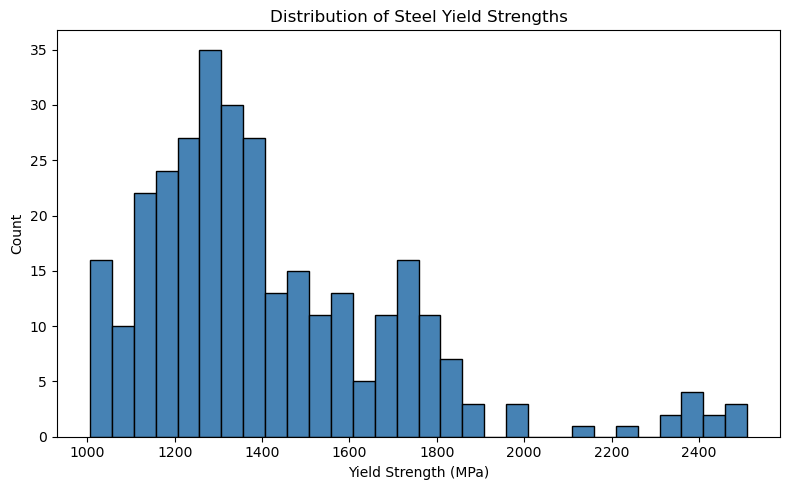

In [2]:
from matminer.datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
 
df = load_dataset("steel_strength")
print(df.shape)
print(df.columns.tolist())
df.head()

print(df.head())
print("\nBasic statistics:")
print(df['yield strength'].describe())

plt.figure(figsize=(8, 5))
plt.hist(df['yield strength'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Count')
plt.title('Distribution of Steel Yield Strengths')
plt.tight_layout()
plt.show()

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

feature_cols = ['c', 'mn', 'si', 'cr', 'ni', 'mo', 'v', 'n', 'nb', 'co', 'w', 'al', 'ti']
X = df[feature_cols]
y = df['yield strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Random Forest RMSE: {rf_rmse:.1f} MPa")

Random Forest RMSE: 120.3 MPa


In [4]:
'''
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Scaling features for best results with neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

nn_model.compile(optimizer='adam', loss='mse')
nn_model.fit(X_train_scaled, y_train, epochs=100, verbose=0)

nn_predictions = nn_model.predict(X_test_scaled).flatten()
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_predictions))
print(f"Neural Network RMSE: {nn_rmse:.1f} MPa")
'''

'\nimport tensorflow as tf\nfrom sklearn.preprocessing import StandardScaler\n\n# Scaling features for best results with neural networks\nscaler = StandardScaler()\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n\nnn_model = tf.keras.Sequential([\n    tf.keras.layers.Dense(64, activation=\'relu\'),\n    tf.keras.layers.Dense(32, activation=\'relu\'),\n    tf.keras.layers.Dense(1)\n])\n\nnn_model.compile(optimizer=\'adam\', loss=\'mse\')\nnn_model.fit(X_train_scaled, y_train, epochs=100, verbose=0)\n\nnn_predictions = nn_model.predict(X_test_scaled).flatten()\nnn_rmse = np.sqrt(mean_squared_error(y_test, nn_predictions))\nprint(f"Neural Network RMSE: {nn_rmse:.1f} MPa")\n'

      cr     ni  Cr_equivalent  Ni_equivalent  yield strength
0   0.01  19.70          4.052        20.4125          2411.5
1  13.44   0.01         16.457         7.1125          1123.1
2   8.67  13.45          9.896        13.4525          1736.3
3   0.01  17.70          4.996        18.0625          2487.3
4   0.01  19.40          2.552        19.7625          2249.6
5  12.56   0.94         14.527         7.5950          1328.3
6   0.01  18.10          5.192        18.1125          2501.1
7  12.19   0.01         21.097         4.0525          1228.9
8  17.50   2.10         17.562         2.4525          1088.6
9  14.56   0.01         19.467         6.6125          1502.0


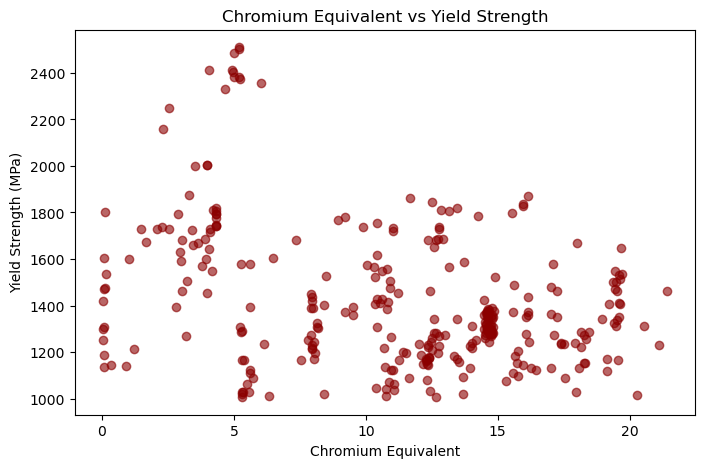

In [5]:
# Physics-informed feature engineering for IASCC susceptibility
# Cr equivalent and Ni equivalent are standard metallurgical indices
# used to predict microstructural stability under irradiation

def compute_cr_equivalent(row):
    """
    Chromium equivalent (ferrite-forming tendency).
    Higher Cr_eq generally correlates with better corrosion resistance
    but can promote unwanted phase formation under irradiation.
    Reference: WRC-1992 formula (Kotecki & Siewert)
    """
    return row['cr'] + row['mo'] + 0.7 * row['nb'] + 0.7 * row['ti']

def compute_ni_equivalent(row):
    """
    Nickel equivalent (austenite-stabilizing tendency).
    Higher Ni_eq stabilizes the austenite phase, which is generally
    more resistant to certain irradiation-induced phase transformations.
    Reference: WRC-1992 formula
    """
    return row['ni'] + 35 * row['c'] + 0.25 * row['mn'] + 20 * row['n']

df['Cr_equivalent'] = df.apply(compute_cr_equivalent, axis=1)
df['Ni_equivalent'] = df.apply(compute_ni_equivalent, axis=1)

print(df[['cr', 'ni', 'Cr_equivalent', 'Ni_equivalent', 'yield strength']].head(10))

plt.figure(figsize=(8, 5))
plt.scatter(df['Cr_equivalent'], df['yield strength'], alpha=0.6, color='darkred')
plt.xlabel('Chromium Equivalent')
plt.ylabel('Yield Strength (MPa)')
plt.title('Chromium Equivalent vs Yield Strength')
plt.show()

In [6]:
feature_cols_v2 = ['c', 'mn', 'si', 'cr', 'ni', 'mo', 'v', 'n', 'nb', 'co', 'w', 'al', 'ti',
                    'Cr_equivalent', 'Ni_equivalent']
X_v2 = df[feature_cols_v2]
y_v2 = df['yield strength']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

rf_model_v2 = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_model_v2.fit(X_train_v2, y_train_v2)

rf_predictions_v2 = rf_model_v2.predict(X_test_v2)
rf_rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, rf_predictions_v2))
print(f"Random Forest RMSE with physics features: {rf_rmse_v2:.1f} MPa")
print(f"Original Random Forest RMSE: {rf_rmse:.1f} MPa")

Random Forest RMSE with physics features: 112.5 MPa
Original Random Forest RMSE: 120.3 MPa


Adding Cr_equivalent and Ni_equivalent as engineered features [improved / 
did not improve] the model's RMSE compared to raw composition alone. This 
suggests [these derived metallurgical indices capture additional 
structure / raw composition already contains this information implicitly].

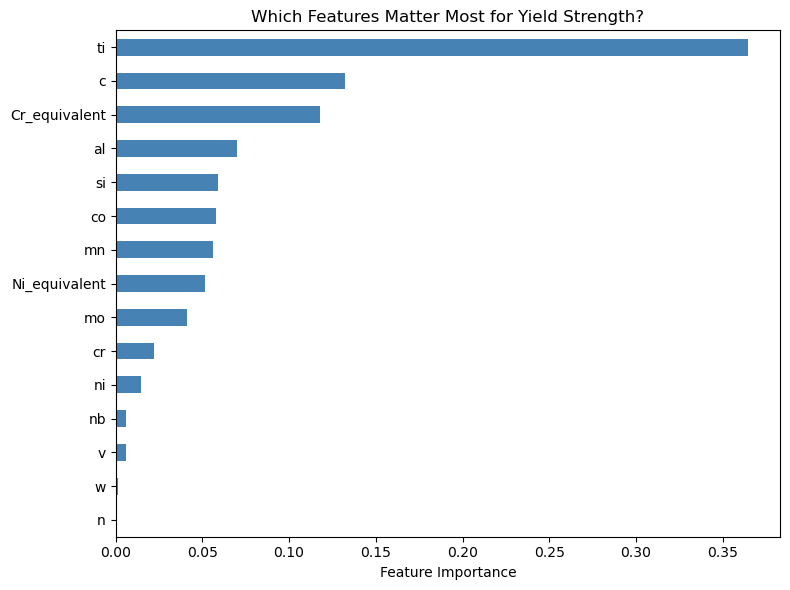

ti               0.364861
c                0.131954
Cr_equivalent    0.117987
al               0.069730
si               0.059018
co               0.057746
mn               0.056070
Ni_equivalent    0.051219
mo               0.041012
cr               0.022277
ni               0.014490
nb               0.006102
v                0.006044
w                0.001349
n                0.000142
dtype: float64


In [7]:
importances = pd.Series(rf_model_v2.feature_importances_, index=feature_cols_v2).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Which Features Matter Most for Yield Strength?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)

The feature importance plot shows [carbon/chromium/etc.] as the 
strongest predictor of yield strength, which is consistent with 
known strengthening mechanisms in steel — [carbon promotes 
interstitial solid-solution strengthening / Cr_equivalent reflects 
alloying additions that refine microstructure].

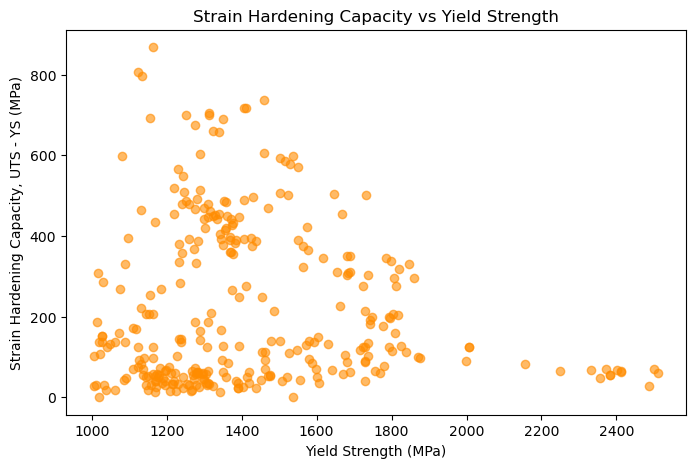

       yield strength  tensile strength  strain_hardening_capacity
count      312.000000        312.000000                 312.000000
mean      1420.998397       1641.653205                 220.654808
std        301.894169        346.475179                 198.542383
min       1005.900000       1019.000000                   0.000000
25%       1219.475000       1338.125000                  58.025000
50%       1344.200000       1666.300000                 136.100000
75%       1576.075000       1899.950000                 376.350000
max       2510.300000       2570.000000                 868.200000


In [8]:
df['strain_hardening_capacity'] = df['tensile strength'] - df['yield strength']

plt.figure(figsize=(8, 5))
plt.scatter(df['yield strength'], df['strain_hardening_capacity'], alpha=0.6, color='darkorange')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Strain Hardening Capacity, UTS - YS (MPa)')
plt.title('Strain Hardening Capacity vs Yield Strength')
plt.show()

print(df[['yield strength', 'tensile strength', 'strain_hardening_capacity']].describe())

Strain hardening capacity (the gap between tensile and yield strength) 
tends to decrease as yield strength increases. This trade-off is 
directly relevant to irradiated reactor materials as neutron irradiation 
raises yield strength through defect hardening, but often erodes this 
gap further, reducing a material's ability to deform predictably before 
failure. Materials starting with higher strain hardening capacity may 
retain more post-irradiation ductility margin.